In [1]:
import functools
import jax
import os

from datetime import datetime
from jax import numpy as jp
import matplotlib.pyplot as plt

from IPython.display import HTML, clear_output

import brax
import flax
from brax import envs
from brax.io import model
from brax.io import json
from brax.io import html
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import train as sac

In [2]:
"""Trains a 2D walker to run in the +x direction."""

from typing import Tuple

from brax import base
from brax.envs.base import PipelineEnv, State
from brax.io import mjcf
from etils import epath
import jax
from jax import numpy as jp


class Walker2dWithObstacles(PipelineEnv):

    def __init__(
        self,
        forward_reward_weight: float = 1.0,
        ctrl_cost_weight: float = 1e-3,
        healthy_reward: float = 1.0,
        terminate_when_unhealthy: bool = True,
        healthy_z_range: Tuple[float, float] = (0.1, 3.0),  # (0.8, 2.0)
        healthy_angle_range=(-1.0, 1.0),
        reset_noise_scale=5e-3,
        exclude_current_positions_from_observation=True,
        # New obstacle parameters
        obstacle_height: float = 0.2,
        obstacle_width: float = 0.2,
        obstacle_spacing: float = 2.0,
        n_obstacles: int = 5,
        backend='generalized',
        **kwargs
    ):

        path = epath.resource_path('brax') / 'envs/assets/walker2d.xml'
        # sys = mjcf.load(path)

        # Create and add obstacles
        sys = self._add_obstacles(path, obstacle_height, obstacle_width,
                           obstacle_spacing, n_obstacles)

        n_frames = 4
        kwargs['n_frames'] = kwargs.get('n_frames', n_frames)

        super().__init__(sys=sys, backend=backend, **kwargs)

        self._forward_reward_weight = forward_reward_weight
        self._ctrl_cost_weight = ctrl_cost_weight
        self._healthy_reward = healthy_reward
        self._terminate_when_unhealthy = terminate_when_unhealthy
        self._healthy_z_range = healthy_z_range
        self._healthy_angle_range = healthy_angle_range
        self._reset_noise_scale = reset_noise_scale
        self._exclude_current_positions_from_observation = (
            exclude_current_positions_from_observation
        )

        self._obstacle_height = obstacle_height
        self._obstacle_width = obstacle_width
        self._obstacle_spacing = obstacle_spacing
        self._n_obstacles = n_obstacles


    def _add_obstacles(self, path, height, width, spacing, n_obstacles):
        with open(path, 'r') as fd:
            xml_string = fd.read()
        import xml.etree.ElementTree as ET
        root = ET.fromstring(xml_string)
        worldbody = root.find('worldbody')
        for i in range(n_obstacles):
            x_pos = (i + 1) * spacing

            # Create obstacle body
            body = ET.SubElement(worldbody, 'body')
            body.set('name', f'obstacle_{i}')
            body.set('pos', f'{x_pos} 0 {height/2}')

            # Add geom to body
            geom = ET.SubElement(body, 'geom')
            geom.set('type', 'box')
            geom.set('size', f'{width/2} 0.1 {height/2}')
            geom.set('rgba', '0.7 0.7 0.7 1')
            geom.set('mass', '0')
            geom.set('contype', '1')
            geom.set('conaffinity', '1')

        # Convert back to string
        new_xml = ET.tostring(root, encoding='unicode')
        with open('./logs/walker2d_modified.xml', 'w') as fd:
            fd.write(new_xml)

        # Load modified XML
        sys = mjcf.load('./logs/walker2d_modified.xml')

        return sys


    def reset(self, rng: jax.Array) -> State:
        """Resets the environment to an initial state."""
        rng, rng1, rng2 = jax.random.split(rng, 3)

        low, hi = -self._reset_noise_scale, self._reset_noise_scale
        qpos = self.sys.init_q + jax.random.uniform(
            rng1, (self.sys.q_size(),), minval=low, maxval=hi
        )
        qvel = jax.random.uniform(
            rng2, (self.sys.qd_size(),), minval=low, maxval=hi
        )

        pipeline_state = self.pipeline_init(qpos, qvel)

        obs = self._get_obs(pipeline_state)
        reward, done, zero = jp.zeros(3)
        metrics = {
            'reward_forward': zero,
            'reward_ctrl': zero,
            'reward_healthy': zero,
            'x_position': zero,
            'x_velocity': zero,
        }
        return State(pipeline_state, obs, reward, done, metrics)

    def step(self, state: State, action: jax.Array) -> State:
        """Runs one timestep of the environment's dynamics."""
        pipeline_state0 = state.pipeline_state
        assert pipeline_state0 is not None
        pipeline_state = self.pipeline_step(pipeline_state0, action)

        x_velocity = (
            pipeline_state.x.pos[0, 0] - pipeline_state0.x.pos[0, 0]
        ) / self.dt
        forward_reward = self._forward_reward_weight * x_velocity

        z, angle = pipeline_state.x.pos[0, 2], pipeline_state.q[2]
        min_z, max_z = self._healthy_z_range
        min_angle, max_angle = self._healthy_angle_range
        is_healthy = (
            (z > min_z) & (z < max_z) * (angle > min_angle) & (angle < max_angle)
        )
        if self._terminate_when_unhealthy:
          healthy_reward = self._healthy_reward
        else:
          healthy_reward = self._healthy_reward * is_healthy

        ctrl_cost = self._ctrl_cost_weight * jp.sum(jp.square(action))

        obs = self._get_obs(pipeline_state)
        reward = forward_reward + healthy_reward - ctrl_cost
        done = 1.0 - is_healthy if self._terminate_when_unhealthy else 0.0
        state.metrics.update(
            reward_forward=forward_reward,
            reward_ctrl=-ctrl_cost,
            reward_healthy=healthy_reward,
            x_position=pipeline_state.x.pos[0, 0],
            x_velocity=x_velocity,
        )

        return state.replace(
            pipeline_state=pipeline_state, obs=obs, reward=reward, done=done
        )

    def _get_obs(self, pipeline_state: base.State) -> jax.Array:
        """Returns the environment observations."""
        position = pipeline_state.q
        position = position.at[1].set(pipeline_state.x.pos[0, 2])
        velocity = jp.clip(pipeline_state.qd, -10, 10)

        if self._exclude_current_positions_from_observation:
          position = position[1:]

        return jp.concatenate((position, velocity))


class HalfcheetahWithObstacles(PipelineEnv):

    def __init__(
        self,
        forward_reward_weight=1.0,
        ctrl_cost_weight=0.1,
        reset_noise_scale=0.1,
        exclude_current_positions_from_observation=True,
        # New obstacle parameters
        obstacle_height: float = 0.2,
        obstacle_width: float = 0.2,
        obstacle_spacing: float = 2.0,
        n_obstacles: int = 5,
        backend='generalized',
        **kwargs
    ):
        path = epath.resource_path('brax') / 'envs/assets/half_cheetah.xml'
        sys = mjcf.load(path)

        n_frames = 5

        # Create and add obstacles
        sys = self._add_obstacles(path, obstacle_height, obstacle_width,
                           obstacle_spacing, n_obstacles)

        if backend in ['spring', 'positional']:
            sys = sys.tree_replace({'opt.timestep': 0.003125})
            n_frames = 16
            gear = jp.array([120, 90, 60, 120, 100, 100])
            sys = sys.replace(actuator=sys.actuator.replace(gear=gear))

        kwargs['n_frames'] = kwargs.get('n_frames', n_frames)

        super().__init__(sys=sys, backend=backend, **kwargs)

        self._forward_reward_weight = forward_reward_weight
        self._ctrl_cost_weight = ctrl_cost_weight
        self._reset_noise_scale = reset_noise_scale
        self._exclude_current_positions_from_observation = (
            exclude_current_positions_from_observation
        )

        self._obstacle_height = obstacle_height
        self._obstacle_width = obstacle_width
        self._obstacle_spacing = obstacle_spacing
        self._n_obstacles = n_obstacles

    def _add_obstacles(self, path, height, width, spacing, n_obstacles):
        with open(path, 'r') as fd:
            xml_string = fd.read()
        import xml.etree.ElementTree as ET
        root = ET.fromstring(xml_string)
        worldbody = root.find('worldbody')
        for i in range(n_obstacles):
            x_pos = (i + 1) * spacing

            # Create obstacle body
            body = ET.SubElement(worldbody, 'body')
            body.set('name', f'obstacle_{i}')
            body.set('pos', f'{x_pos} 0 {height/2}')

            # Add geom to body
            geom = ET.SubElement(body, 'geom')
            geom.set('type', 'box')
            geom.set('size', f'{width/2} 0.1 {height/2}')
            geom.set('rgba', '0.7 0.7 0.7 1')
            geom.set('mass', '0')
            geom.set('contype', '1')
            geom.set('conaffinity', '1')

        # Convert back to string
        new_xml = ET.tostring(root, encoding='unicode')
        with open('./logs/walker2d_modified.xml', 'w') as fd:
            fd.write(new_xml)

        # Load modified XML
        sys = mjcf.load('./logs/walker2d_modified.xml')

        return sys

    def reset(self, rng: jax.Array) -> State:
        """Resets the environment to an initial state."""
        rng, rng1, rng2 = jax.random.split(rng, 3)

        low, hi = -self._reset_noise_scale, self._reset_noise_scale
        qpos = self.sys.init_q + jax.random.uniform(
            rng1, (self.sys.q_size(),), minval=low, maxval=hi
        )
        qvel = hi * jax.random.normal(rng2, (self.sys.qd_size(),))

        pipeline_state = self.pipeline_init(qpos, qvel)

        obs = self._get_obs(pipeline_state)
        reward, done, zero = jp.zeros(3)
        metrics = {
            'x_position': zero,
            'x_velocity': zero,
            'reward_ctrl': zero,
            'reward_run': zero,
        }
        return State(pipeline_state, obs, reward, done, metrics)

    def step(self, state: State, action: jax.Array) -> State:
        """Runs one timestep of the environment's dynamics."""
        pipeline_state0 = state.pipeline_state
        assert pipeline_state0 is not None
        pipeline_state = self.pipeline_step(pipeline_state0, action)

        x_velocity = (
            pipeline_state.x.pos[0, 0] - pipeline_state0.x.pos[0, 0]
        ) / self.dt
        forward_reward = self._forward_reward_weight * x_velocity
        ctrl_cost = self._ctrl_cost_weight * jp.sum(jp.square(action))

        obs = self._get_obs(pipeline_state)
        reward = forward_reward - ctrl_cost
        state.metrics.update(
            x_position=pipeline_state.x.pos[0, 0],
            x_velocity=x_velocity,
            reward_run=forward_reward,
            reward_ctrl=-ctrl_cost,
        )

        return state.replace(pipeline_state=pipeline_state, obs=obs, reward=reward)

    def _get_obs(self, pipeline_state: base.State) -> jax.Array:
        """Returns the environment observations."""
        position = pipeline_state.q
        velocity = pipeline_state.qd

        if self._exclude_current_positions_from_observation:
          position = position[1:]

        return jp.concatenate((position, velocity))


In [4]:
env = HalfcheetahWithObstacles(
    # healthy_z_range=(0.1, 3.0),  # (0.8, 2.0)
    # healthy_angle_range=(-1.0, 1.0),
    # reset_noise_scale=5e-3,
    # exclude_current_positions_from_observation=True,
    # New obstacle parameters
    obstacle_height=0.2,
    obstacle_width=0.2,
    obstacle_spacing=1.0,
    n_obstacles=100,
    backend='spring',
)
state = jax.jit(env.reset)(rng=jax.random.PRNGKey(seed=0))

HTML(html.render(env.sys, [state.pipeline_state]))

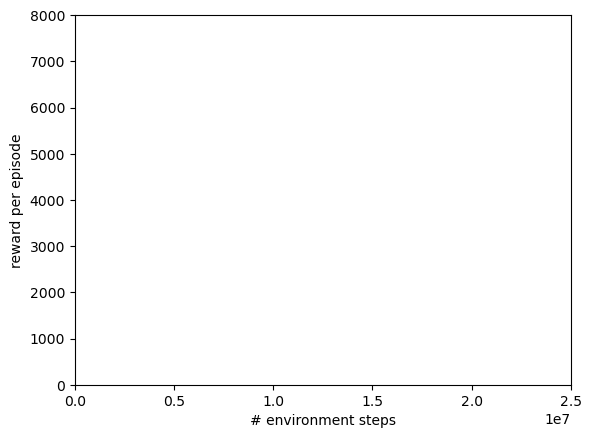

In [ ]:
#@title Training
env_name='halfcheetah'
# We determined some reasonable hyperparameters offline and share them here.
train_fn = {
  'inverted_pendulum': functools.partial(ppo.train, num_timesteps=2_000_000, num_evals=20, reward_scaling=10, episode_length=1000, normalize_observations=True, action_repeat=1, unroll_length=5, num_minibatches=32, num_updates_per_batch=4, discounting=0.97, learning_rate=3e-4, entropy_cost=1e-2, num_envs=2048, batch_size=1024, seed=1),
  'inverted_double_pendulum': functools.partial(ppo.train, num_timesteps=20_000_000, num_evals=20, reward_scaling=10, episode_length=1000, normalize_observations=True, action_repeat=1, unroll_length=5, num_minibatches=32, num_updates_per_batch=4, discounting=0.97, learning_rate=3e-4, entropy_cost=1e-2, num_envs=2048, batch_size=1024, seed=1),
  'ant': functools.partial(ppo.train,  num_timesteps=50_000_000, num_evals=10, reward_scaling=10, episode_length=1000, normalize_observations=True, action_repeat=1, unroll_length=5, num_minibatches=32, num_updates_per_batch=4, discounting=0.97, learning_rate=3e-4, entropy_cost=1e-2, num_envs=4096, batch_size=2048, seed=1),
  'humanoid': functools.partial(ppo.train,  num_timesteps=50_000_000, num_evals=10, reward_scaling=0.1, episode_length=1000, normalize_observations=True, action_repeat=1, unroll_length=10, num_minibatches=32, num_updates_per_batch=8, discounting=0.97, learning_rate=3e-4, entropy_cost=1e-3, num_envs=2048, batch_size=1024, seed=1),
  'reacher': functools.partial(ppo.train, num_timesteps=50_000_000, num_evals=20, reward_scaling=5, episode_length=1000, normalize_observations=True, action_repeat=4, unroll_length=50, num_minibatches=32, num_updates_per_batch=8, discounting=0.95, learning_rate=3e-4, entropy_cost=1e-3, num_envs=2048, batch_size=256, max_devices_per_host=8, seed=1),
  'humanoidstandup': functools.partial(ppo.train, num_timesteps=100_000_000, num_evals=20, reward_scaling=0.1, episode_length=1000, normalize_observations=True, action_repeat=1, unroll_length=15, num_minibatches=32, num_updates_per_batch=8, discounting=0.97, learning_rate=6e-4, entropy_cost=1e-2, num_envs=2048, batch_size=1024, seed=1),
  # 'hopper': functools.partial(sac.train, num_timesteps=6_553_600, num_evals=20, reward_scaling=30, episode_length=1000, normalize_observations=True, action_repeat=1, discounting=0.997, learning_rate=6e-4, num_envs=128, batch_size=512, grad_updates_per_step=64, max_devices_per_host=1, max_replay_size=1048576, min_replay_size=8192, seed=1),
  'walker2d': functools.partial(sac.train, num_timesteps=7_864_320, num_evals=20, reward_scaling=5, episode_length=1000, normalize_observations=True, action_repeat=1, discounting=0.997, learning_rate=6e-4, num_envs=128, batch_size=128, grad_updates_per_step=32, max_devices_per_host=1, max_replay_size=1048576, min_replay_size=8192, seed=1),
  'halfcheetah': functools.partial(ppo.train, num_timesteps=25_000_000, num_evals=3, reward_scaling=30, episode_length=1000, normalize_observations=True, action_repeat=1, unroll_length=20, num_minibatches=32, num_updates_per_batch=8, discounting=0.97, learning_rate=3e-4, entropy_cost=0.001, num_envs=2048, batch_size=512, seed=3),
  'pusher': functools.partial(ppo.train, num_timesteps=50_000_000, num_evals=20, reward_scaling=5, episode_length=1000, normalize_observations=True, action_repeat=1, unroll_length=30, num_minibatches=16, num_updates_per_batch=8, discounting=0.95, learning_rate=3e-4,entropy_cost=1e-2, num_envs=2048, batch_size=512, seed=3),
}[env_name]


# train_fn = functools.partial(
#     sac.train,
#     num_timesteps=5_000_000,
#     num_evals=3, 
#     reward_scaling=5,
#     episode_length=1000, 
#     normalize_observations=True, 
#     action_repeat=1, 
#     discounting=0.997, 
#     learning_rate=6e-4, 
#     num_envs=128, 
#     batch_size=128, 
#     grad_updates_per_step=32, 
#     max_devices_per_host=1, 
#     max_replay_size=1048576, 
#     min_replay_size=8192, 
#     seed=1,
# )

# max_y = {'ant': 8000, 'halfcheetah': 8000, 'hopper': 2500, 'humanoid': 13000, 'humanoidstandup': 75_000, 'reacher': 5, 'walker2d': 5000, 'pusher': 0}[env_name]
# min_y = {'reacher': -100, 'pusher': -150}.get(env_name, 0)

xdata, ydata = [], []
times = [datetime.now()]

def progress(num_steps, metrics):
  times.append(datetime.now())
  xdata.append(num_steps)
  ydata.append(metrics['eval/episode_reward'])
  clear_output(wait=True)
  plt.xlim([0, train_fn.keywords['num_timesteps']])
  plt.ylim([0, 8000])
  plt.xlabel('# environment steps')
  plt.ylabel('reward per episode')
  plt.plot(xdata, ydata)
  plt.show()

make_inference_fn, params, _ = train_fn(environment=env, progress_fn=progress)

print(f'time to jit: {times[1] - times[0]}')
print(f'time to train: {times[-1] - times[1]}')

In [7]:
inference_fn = make_inference_fn(params)
jit_env_reset = jax.jit(env.reset)
jit_env_step = jax.jit(env.step)
jit_inference_fn = jax.jit(inference_fn)

rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
  rollout.append(state.pipeline_state)
  act_rng, rng = jax.random.split(rng)
  act, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_env_step(state, act)

HTML(html.render(env.sys.tree_replace({'opt.timestep': env.dt}), rollout))

NameError: name 'PipelineEnv' is not defined